In [1]:
pip install snntorch torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [9]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
from snntorch import utils
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
# Hyperparameters
batch_size = 128
num_epochs = 5
learning_rate = 1e-3
num_steps = 25  # Time steps for the spiking neuron

In [4]:
# Transform
transform = transforms.Compose([
    transforms.ToTensor()
])

In [5]:
# Load data
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.19MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


In [6]:
# Network
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        beta = 0.95
        self.fc1 = nn.Linear(28*28, 1000)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())
        self.fc2 = nn.Linear(1000, 10)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x, num_steps):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)

        return torch.stack(spk2_rec).sum(dim=0)

model = SNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SNN(
  (fc1): Linear(in_features=784, out_features=1000, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
  (lif2): Leaky()
)

In [7]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Epoch 1/5, Loss: 0.0637, Accuracy: 98.16%
Epoch 2/5, Loss: 0.0551, Accuracy: 98.43%
Epoch 3/5, Loss: 0.0560, Accuracy: 98.44%
Epoch 4/5, Loss: 0.0513, Accuracy: 98.52%
Epoch 5/5, Loss: 0.0573, Accuracy: 98.48%


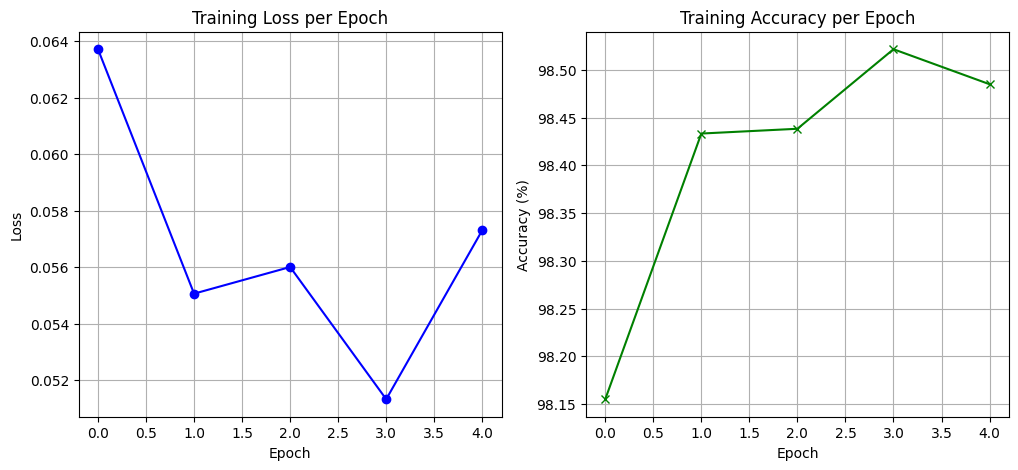

In [30]:
import matplotlib.pyplot as plt

loss_values = []
accuracy_values = []

for epoch in range(num_epochs):
    epoch_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images, num_steps)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = epoch_loss / len(train_loader)
    accuracy = 100 * correct / total

    loss_values.append(avg_loss)
    accuracy_values.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Plotting
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(loss_values, marker='o', color='blue')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracy_values, marker='x', color='green')
plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

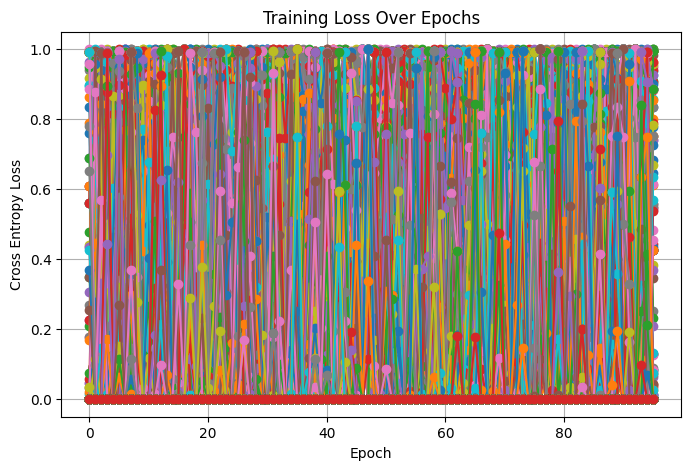

In [31]:
# Plot training loss of the images
plt.figure(figsize=(8,5))
plt.plot(images, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()

In [32]:
# Save model
torch.save(model.state_dict(), "snn_mnist.pth")

In [33]:
# To download the model from Colab
from google.colab import files
files.download("snn_mnist.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
!pip install streamlit pyngrok snntorch torch torchvision pillow --quiet

In [34]:
from google.colab import files
uploaded = files.upload()

Saving snn_mnist.pth to snn_mnist (2).pth


In [35]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
from torchvision import transforms
from PIL import Image
import io

# SNN model definition
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        beta = 0.95
        self.fc1 = nn.Linear(28*28, 1000)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())
        self.fc2 = nn.Linear(1000, 10)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x, num_steps=25):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)

        return torch.stack(spk2_rec).sum(dim=0)

# Load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SNN().to(device)
model.load_state_dict(torch.load("snn_mnist.pth", map_location=device))
model.eval()

# Streamlit interface
st.title("🧠 SNN MNIST Classifier")
st.write("Upload a 28x28 grayscale digit image (PNG or JPG) to classify it using your trained Spiking Neural Network.")

uploaded_file = st.file_uploader("Upload image...", type=["png", "jpg", "jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("L")
    st.image(image, caption="Uploaded Digit", use_column_width=True)

    transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])

    input_tensor = transform(image).view(1, -1).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        prediction = output.argmax(1).item()

    st.success(f"Predicted Digit: {prediction}")

Overwriting app.py


In [36]:
from pyngrok import ngrok

# Paste your ngrok authtoken here
ngrok.set_auth_token("2pG70TdB4oq7cPHCyzkBCpJVUYV_DXwNAvDWSRkvrbDsJGHg")

In [37]:
# Start Streamlit app in the background
!streamlit run app.py &>/content/logs.txt &

# Wait a bit for the app to launch (important!)
import time
time.sleep(3)

# Connect to the streamlit app
public_url = ngrok.connect(addr=8501, proto="http")
print(f"🌐 Streamlit is live at: {public_url}")

🌐 Streamlit is live at: NgrokTunnel: "https://365b61a642fb.ngrok-free.app" -> "http://localhost:8501"
